# Political Compass MCQ analysis — primary models


    This is the complete release analysis for the paper's four Gemma 3 IT and
    four Qwen3 checkpoints. It uses the released configuration-score table,
    where each row is one sampled prompt configuration after its 62 response
    distributions have been mapped to economic and social coordinates.

    The generated scorer is not redistributed. Consequently, this notebook
    starts from the released coordinates and does not pretend to reconstruct
    them from candidate probabilities. The separate instrument notebook shows
    how the scorer was reconstructed locally. When `data/release/` is present,
    the notebook reads the pinned Hugging Face `analysis_ready` tables; it
    otherwise uses the byte-equivalent tracked compact tables.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ANALYSIS_DIR = Path.cwd()
if not (ANALYSIS_DIR / 'core.py').exists():
    candidates = [Path('tasks/political-compass/analysis').resolve(), Path.cwd().parent]
    ANALYSIS_DIR = next((path for path in candidates if (path / 'core.py').exists()), None)
if ANALYSIS_DIR is None:
    raise FileNotFoundError('Run from the repository root or tasks/political-compass/analysis.')
sys.path.insert(0, str(ANALYSIS_DIR))

from core import (
    GEMMA_MODELS, QWEN_MODELS, PRIMARY_MODELS, IDEOLOGY_ORDER,
    load_mcq_configurations, load_chat_configurations, method_order,
    plot_centroid_grid, qwen_think_outcomes, descriptive_factor_spread,
    plot_sensitivity_heatmap, size_label, analysis_table_path,
    read_analysis_table,
)

sns.set_theme(style='whitegrid', context='notebook')
def source_label(path):
    try: return path.relative_to(ANALYSIS_DIR.parents[2])
    except ValueError: return path
print('Political Compass analysis source:')
print('  MCQ:', source_label(analysis_table_path('pct_configuration_scores')))
print('  chat:', source_label(analysis_table_path('chat_configuration_scores')))

Political Compass analysis source:
  MCQ: /tmp/llm-bias-fresh-analysis/data/analysis_ready/political_compass/pct_configuration_scores.parquet
  chat: /tmp/llm-bias-fresh-analysis/data/analysis_ready/political_compass/chat_configuration_scores.parquet


## Coverage and design balance

        The MCQ experiment crosses eight models, three quantizations, fourteen
        languages and six persona conditions. Every model/persona block has
        the same number of configurations.

In [2]:
mcq = load_mcq_configurations()
coverage = pd.DataFrame({
    'value': [len(mcq), mcq['model'].nunique(), mcq['quantization'].nunique(),
              mcq['language'].nunique(), mcq['ideology'].nunique(), mcq['config_id'].nunique()],
}, index=['configuration rows', 'models', 'quantizations', 'languages', 'personas', 'unique config IDs'])
display(coverage)
display(mcq.groupby(['model', 'ideology'], observed=True).size().unstack())
assert len(mcq) == 43_200
assert set(mcq['model']) == set(PRIMARY_MODELS)
assert mcq.groupby(['model', 'ideology']).size().eq(900).all()

,value
configuration rows,43200
models,8
quantizations,3
languages,14
personas,6
unique config IDs,14400


ideology,authoritarian_left,authoritarian_right,base,centrism,libertarian_left,libertarian_right
model,,,,,,
Qwen3-14B,900,900,900,900,900,900
Qwen3-32B,900,900,900,900,900,900
Qwen3-4B,900,900,900,900,900,900
Qwen3-8B,900,900,900,900,900,900
gemma-3-12b-it,900,900,900,900,900,900
gemma-3-1b-it,900,900,900,900,900,900
gemma-3-27b-it,900,900,900,900,900,900
gemma-3-4b-it,900,900,900,900,900,900


## Configuration distributions and persona centroids

        Small transparent points are individual prompt configurations. Large
        markers are persona means. Ellipses summarize one standard deviation
        along the covariance axes of the
        configuration cloud; they are descriptive, not confidence intervals.
        The plot averages over languages and quantizations.

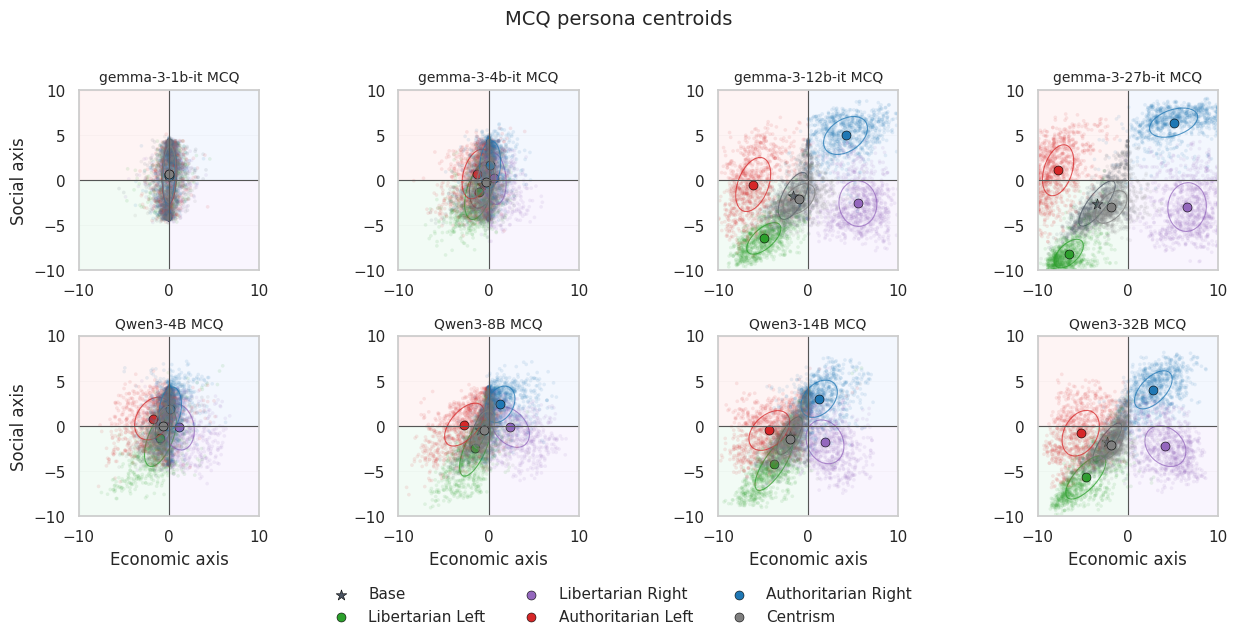

In [3]:
panels = [(f'{model}|mcq', f'{model} MCQ') for model in PRIMARY_MODELS]
plot_frame = mcq.rename(columns={'score_econ': 'economic', 'score_soc': 'social'})
fig = plot_centroid_grid(plot_frame, panels, ncols=4, title='MCQ persona centroids')
plt.show()

## Baseline displacement and persona separation

        `distance_from_origin` is the distance of a condition mean from the
        compass origin. `persona_spread` is the mean distance between each
        non-base persona centroid and that model's base centroid. These are
        compact summaries of this experiment, not quality scores.

In [4]:
centroids = (mcq.groupby(['model', 'ideology'], observed=True)[['score_econ', 'score_soc']]
             .mean().reset_index())
centroids['distance_from_origin'] = np.hypot(centroids['score_econ'], centroids['score_soc'])
base = centroids[centroids.ideology.eq('base')].set_index('model')[['score_econ', 'score_soc']]
shifted = centroids[~centroids.ideology.eq('base')].copy()
shifted['distance_from_base'] = [
    float(np.linalg.norm(row[['score_econ','score_soc']].to_numpy(float) - base.loc[row.model].to_numpy(float)))
    for _, row in shifted.iterrows()
]
summary = (shifted.groupby('model', observed=True)['distance_from_base'].mean()
           .rename('mean persona-centroid distance from base').to_frame()
           .join(centroids[centroids.ideology.eq('base')].set_index('model')['distance_from_origin']))
display(summary.reindex(PRIMARY_MODELS).round(3))

,mean persona-centroid distance from base,distance_from_origin
model,,
gemma-3-1b-it,0.088,0.575
gemma-3-4b-it,1.371,0.936
gemma-3-12b-it,5.429,2.398
gemma-3-27b-it,7.199,4.282
Qwen3-4B,1.347,0.580
Qwen3-8B,2.268,1.067
Qwen3-14B,3.105,2.310
Qwen3-32B,4.480,2.902


## Language-specific position variation

        The table reports the largest distance between a language-specific
        persona centroid and that model/persona's overall centroid. A large
        entry means language matters somewhere in that block; it does not say
        that every language shifts in the same direction.

In [5]:
lang = mcq.groupby(['model','ideology','language'], observed=True)[['score_econ','score_soc']].mean()
overall = mcq.groupby(['model','ideology'], observed=True)[['score_econ','score_soc']].mean()
lang = lang.join(overall, rsuffix='_overall')
lang['centroid_shift'] = np.hypot(lang.score_econ-lang.score_econ_overall,
                                 lang.score_soc-lang.score_soc_overall)
display(lang.groupby(['model','ideology'])['centroid_shift'].max().unstack().reindex(PRIMARY_MODELS).round(2))

ideology,authoritarian_left,authoritarian_right,base,centrism,libertarian_left,libertarian_right
model,,,,,,
gemma-3-1b-it,1.39,1.31,1.15,1.25,1.04,1.04
gemma-3-4b-it,1.67,1.23,1.28,1.03,1.90,1.85
gemma-3-12b-it,2.07,1.94,1.59,1.17,2.18,2.24
gemma-3-27b-it,1.99,3.07,1.65,1.07,1.58,3.04
Qwen3-4B,2.23,2.46,1.57,1.99,3.61,1.89
Qwen3-8B,2.66,1.72,1.84,1.47,3.17,2.20
Qwen3-14B,2.40,2.24,1.80,1.58,3.25,2.49
Qwen3-32B,1.79,2.28,1.38,0.96,2.56,2.64


## Factor sensitivity

        Each factor cell is a standard-deviation-sized contribution in compass
        points from within-persona Type-III ANOVA fits. Stars and p-values are
        intentionally not used as the story: with many configurations, tiny
        differences are readily detectable. Compare magnitudes and recurrence
        instead. `Response Entropy` represents candidate-probability blur.

In [6]:
sensitivity = read_analysis_table('pct_factor_sensitivity')
magnitude_columns = ['Ideology','Total Variation','Residual Jitter','Response Entropy',
                     'quantization_sd','language_sd','context_combo_sd','instr_combo_sd',
                     'key_type_sd','perm_id_sd','persona_combo_sd']
for axis in ['econ','soc']:
    display(sensitivity[sensitivity.axis.eq(axis)].set_index('model')[magnitude_columns]
            .reindex(PRIMARY_MODELS).round(2))

,Ideology,Total Variation,Residual Jitter,Response Entropy,quantization_sd,language_sd,context_combo_sd,instr_combo_sd,key_type_sd,perm_id_sd,persona_combo_sd
model,,,,,,,,,,,
gemma-3-1b-it,0.02,1.32,0.74,1.09,0.05,0.11,0.07,0.11,0.07,0.09,0.07
gemma-3-4b-it,0.76,1.63,1.18,0.96,0.12,0.36,0.31,0.32,0.11,0.18,0.26
gemma-3-12b-it,4.69,1.90,1.43,0.88,0.21,0.60,0.47,0.42,0.22,0.24,0.86
gemma-3-27b-it,5.94,1.87,1.29,0.73,0.14,0.68,0.50,0.73,0.12,0.30,0.86
Qwen3-4B,0.97,2.00,1.12,1.42,0.16,0.63,0.23,0.38,0.13,0.42,0.43
Qwen3-8B,1.86,2.13,1.15,1.46,0.16,0.86,0.25,0.45,0.14,0.33,0.62
Qwen3-14B,2.55,2.27,1.24,1.55,0.13,0.77,0.31,0.50,0.32,0.49,0.74
Qwen3-32B,3.87,2.28,1.23,1.46,0.10,0.79,0.32,0.75,0.49,0.28,0.77


,Ideology,Total Variation,Residual Jitter,Response Entropy,quantization_sd,language_sd,context_combo_sd,instr_combo_sd,key_type_sd,perm_id_sd,persona_combo_sd
model,,,,,,,,,,,
gemma-3-1b-it,0.08,3.23,2.75,0.69,0.05,0.56,0.24,0.53,0.14,1.43,0.28
gemma-3-4b-it,1.06,2.73,2.24,0.64,0.17,0.64,0.66,0.90,0.19,0.73,0.50
gemma-3-12b-it,3.71,2.22,1.66,0.56,0.13,0.63,0.79,0.85,0.20,0.45,0.72
gemma-3-27b-it,4.87,2.12,1.51,0.50,0.17,0.62,0.78,0.96,0.18,0.36,0.67
Qwen3-4B,1.09,2.58,2.11,0.92,0.19,0.83,0.41,0.55,0.23,0.55,0.45
Qwen3-8B,1.56,2.49,1.92,0.96,0.18,0.89,0.51,0.55,0.13,0.59,0.52
Qwen3-14B,2.35,2.35,1.64,1.02,0.12,0.78,0.49,0.67,0.30,0.71,0.65
Qwen3-32B,3.14,2.22,1.58,0.95,0.10,0.55,0.48,0.84,0.48,0.42,0.76


## Quantization and temperature diagnostics

        The released experiment directly supports bf16/8-bit/4-bit comparisons.
        It does **not** directly run ten decoding temperatures. The old research
        notebook's temperature curves were post-hoc transformations of stored
        probabilities, not additional model generations, so they are retained
        only in the historical notebook under `legacy/` and are not presented
        here as an experimental temperature result.

In [7]:
quant = (mcq.groupby(['model','quantization','ideology'], observed=True)[['score_econ','score_soc']]
         .mean().reset_index())
bf16 = quant[quant.quantization.eq('bf16')].set_index(['model','ideology'])
rows=[]
for q in ['8bit','4bit']:
    other=quant[quant.quantization.eq(q)].set_index(['model','ideology'])
    delta=np.hypot(other.score_econ-bf16.score_econ, other.score_soc-bf16.score_soc)
    rows.extend({'model':m,'quantization':q,'mean centroid shift from bf16':v}
                for m,v in delta.groupby(level='model').mean().items())
display(pd.DataFrame(rows).pivot(index='model',columns='quantization',
                                 values='mean centroid shift from bf16').reindex(PRIMARY_MODELS).round(3))

quantization,4bit,8bit
model,,
gemma-3-1b-it,0.126,0.069
gemma-3-4b-it,0.441,0.121
gemma-3-12b-it,0.469,0.060
gemma-3-27b-it,0.402,0.043
Qwen3-4B,0.551,0.094
Qwen3-8B,0.426,0.112
Qwen3-14B,0.387,0.248
Qwen3-32B,0.272,0.062


## Interpretation boundary

        This notebook establishes model-, persona-, language-, quantization-,
        and prompt-factor heterogeneity within the sampled experiment. It does
        not establish one universally hardest quadrant or a monotonic family or
        size law. Proposition-local chat behavior is analyzed separately.